In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [5]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 no

In [6]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing numeric values with the median
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

# Fill missing text/categorical values with the mode
categorical_columns = df.select_dtypes(include="object").columns
for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

# Check again
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

Missing values before cleaning:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Missing values after cleaning:
0


C:\Users\USER\AppData\Local\Temp\ipykernel_10420\1092514920.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [7]:
# Basic statistical summary
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
# Check the different seasons in the dataset
print("Seasons available in the dataset:")
print(df["Season"].value_counts())

Seasons available in the dataset:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [9]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print("Average Yield by Season:")
print(season_yield)

Average Yield by Season:
Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


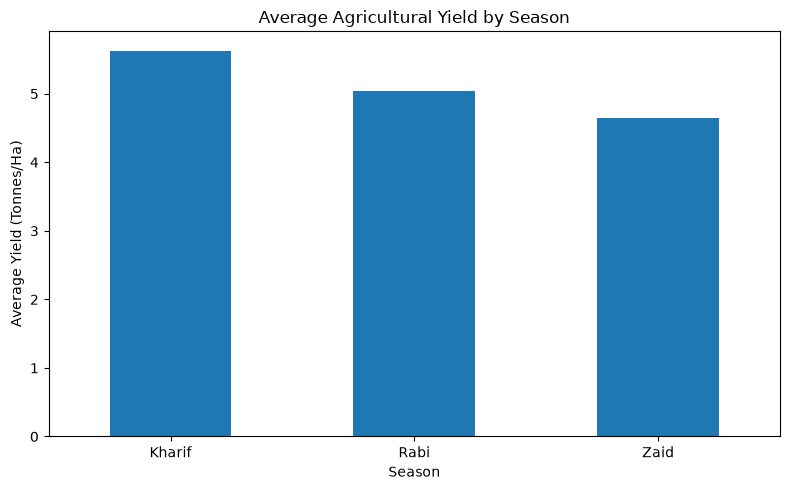

In [10]:
plt.figure(figsize=(8, 5))

season_yield.plot(kind="bar")

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
season_production = (
    df.groupby("Season")["Production_Tonnes"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Production by Season:")
print(season_production)

Average Production by Season:
Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


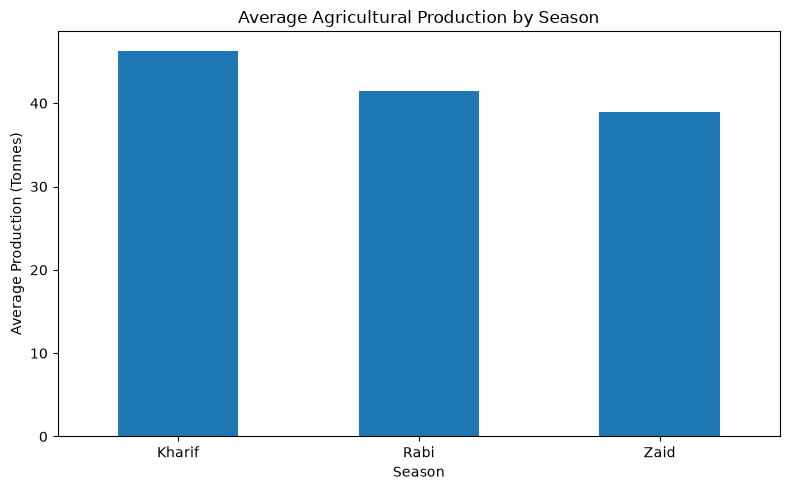

In [12]:
plt.figure(figsize=(8, 5))

season_production.plot(kind="bar")

plt.title("Average Agricultural Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
season_profit = (
    df.groupby("Season")["Profit_INR"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Profit by Season:")
print(season_profit)

Average Profit by Season:
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


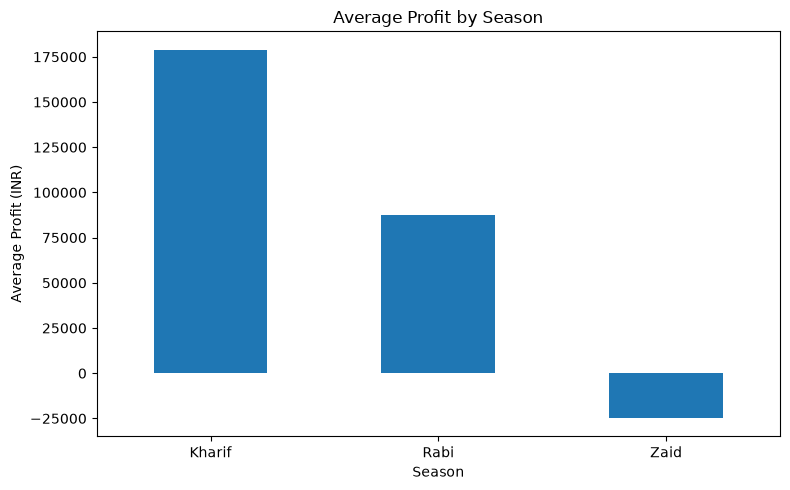

In [14]:
plt.figure(figsize=(8, 5))

season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
season_revenue = (
    df.groupby("Season")["Revenue_INR"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Revenue by Season:")
print(season_revenue)

Average Revenue by Season:
Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


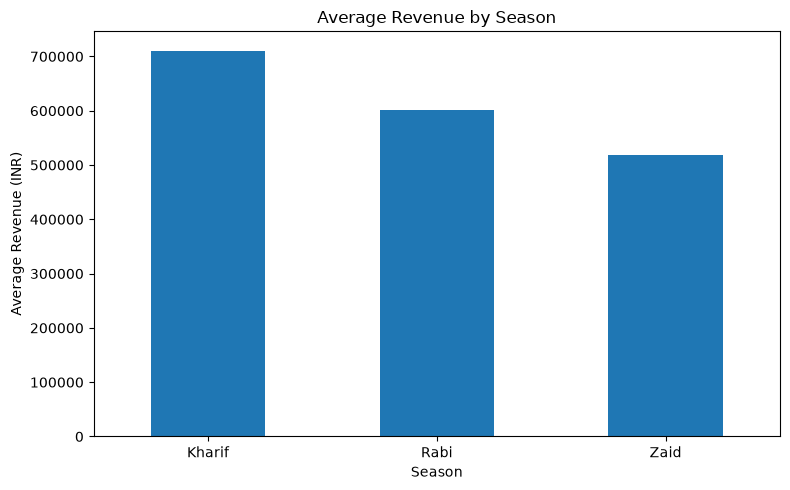

In [16]:
plt.figure(figsize=(8, 5))

season_revenue.plot(kind="bar")

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
plt.figure(figsize=(10, 6))

crop_yield.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'crop_yield' is not defined

<Figure size 1000x600 with 0 Axes>

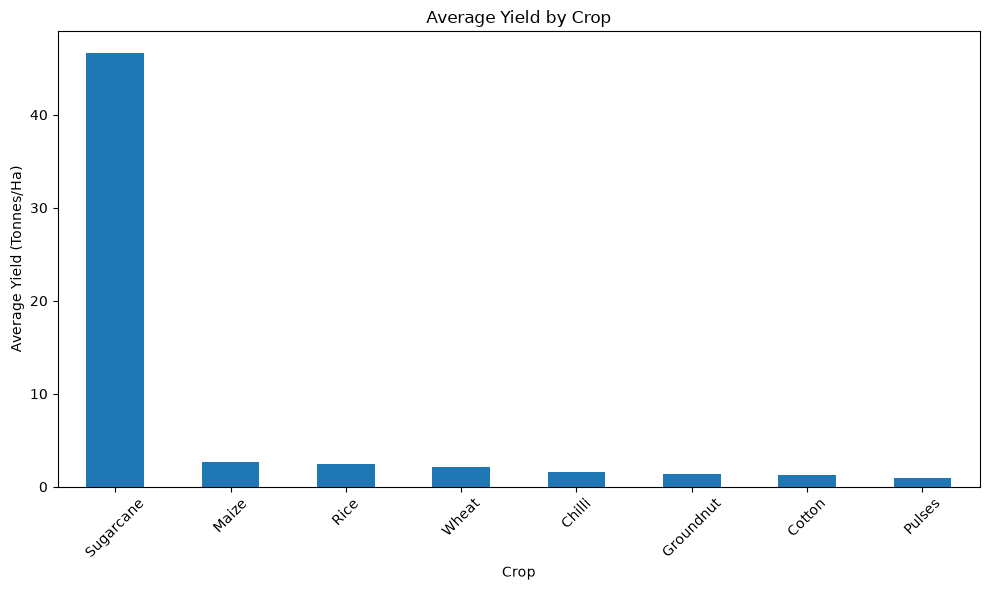

In [19]:
# Calculate average yield by crop
crop_yield = (
    df.groupby("Crop")["Yield_Tonnes_Ha"]
      .mean()
      .sort_values(ascending=False)
)

# Create graph
plt.figure(figsize=(10, 6))
crop_yield.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Irrigation method distribution
irrigation_count = df["Irrigation_Method"].value_counts()

print("Irrigation Methods:")
print(irrigation_count)

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


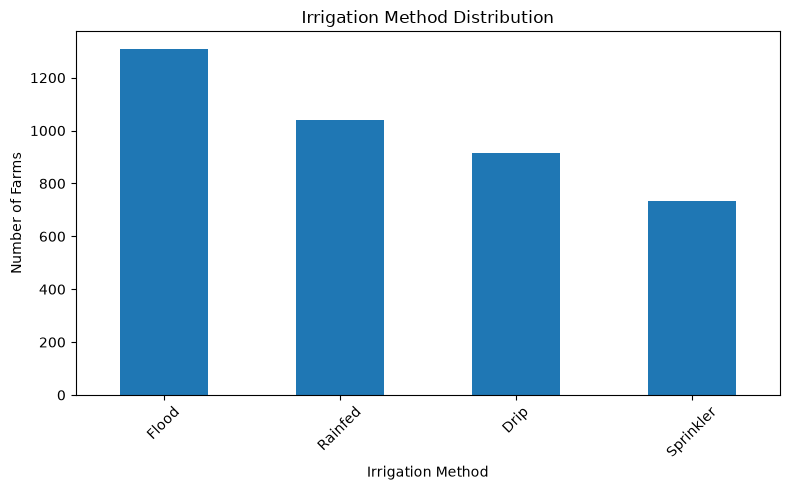

In [21]:
plt.figure(figsize=(8, 5))

irrigation_count.plot(kind="bar")

plt.title("Irrigation Method Distribution")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Average fertilizer and pesticide usage by season
resource_usage = df.groupby("Season")[[
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha"
]].mean()

print("Average Fertilizer and Pesticide Usage by Season:")
print(resource_usage)

Average Fertilizer and Pesticide Usage by Season:
        Fertilizer_kg_ha  Pesticide_Litre_ha
Season                                      
Kharif        187.077965            5.079747
Rabi          185.407068            5.024690
Zaid          184.638047            5.171212


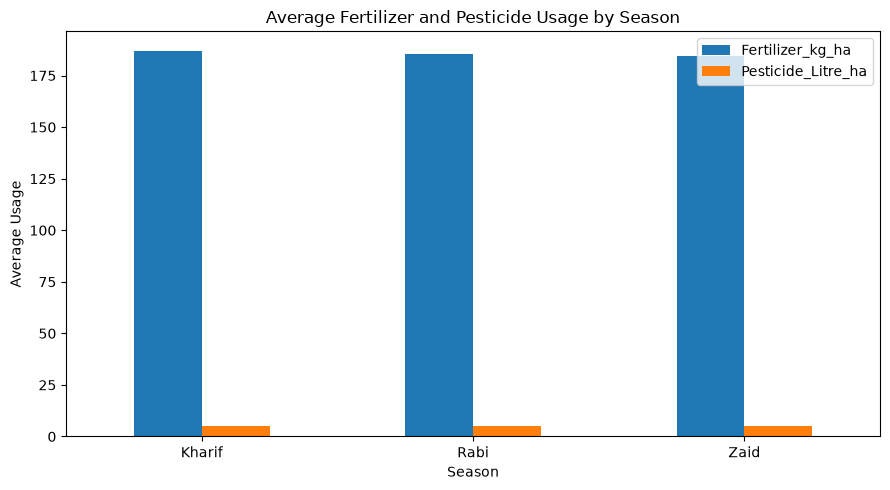

In [23]:
resource_usage.plot(kind="bar", figsize=(9, 5))

plt.title("Average Fertilizer and Pesticide Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Usage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
environment = df.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct"
]].mean()

print("Average Environmental Conditions by Season:")
print(environment)

Average Environmental Conditions by Season:
        Rainfall_mm  Avg_Temperature_C  Humidity_pct
Season                                              
Kharif   849.199663          28.454019     71.812591
Rabi     437.615366          23.489183     57.893178
Zaid     304.654714          31.042088     52.012121


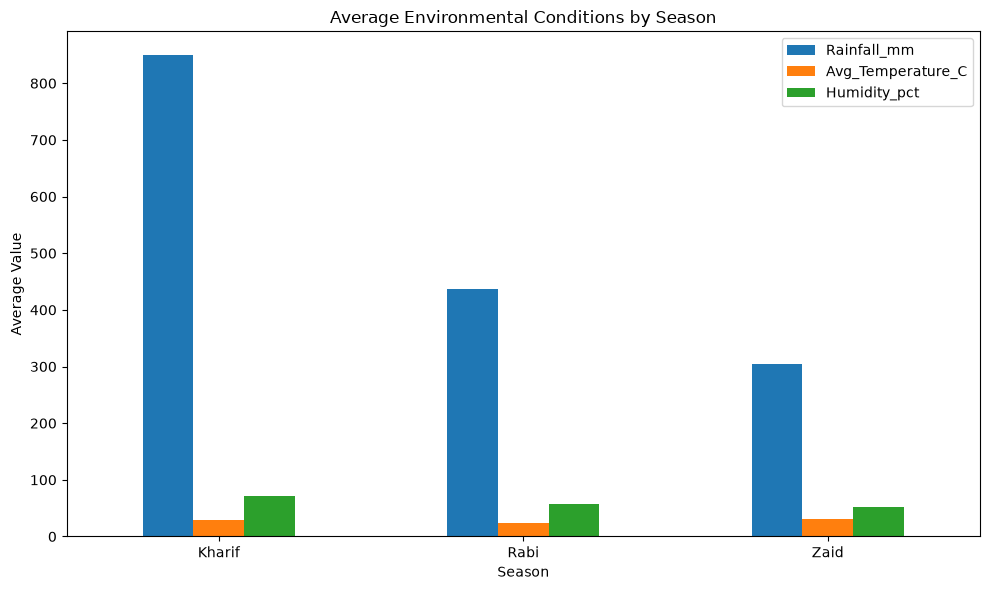

In [25]:
environment.plot(kind="bar", figsize=(10, 6))

plt.title("Average Environmental Conditions by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
water_usage = (
    df.groupby("Season")["Water_Usage_Litres"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Water Usage by Season:")
print(water_usage)

KeyError: 'Column not found: Water_Usage_Litres'

In [27]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [28]:
print([col for col in df.columns if "Water" in col or "water" in col])

['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']


In [29]:
water_usage = (
    df.groupby("Season")["Water_Used_m3"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Water Usage by Season:")
print(water_usage)

Average Water Usage by Season:
Season
Zaid      6419.893939
Kharif    6102.201237
Rabi      5846.987093
Name: Water_Used_m3, dtype: float64


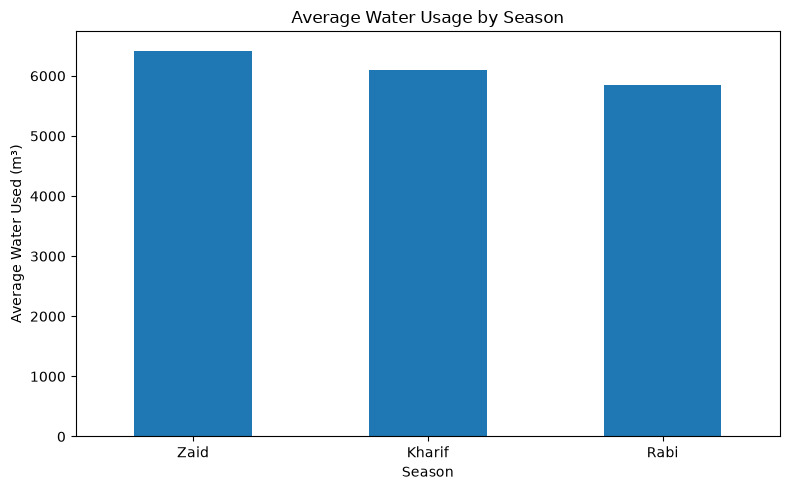

In [30]:
plt.figure(figsize=(8, 5))

water_usage.plot(kind="bar")

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [31]:
state_yield = (
    df.groupby("State")["Yield_Tonnes_Ha"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Yield by State:")
print(state_yield)

Average Yield by State:
State
Punjab            6.121116
Karnataka         5.685481
Gujarat           5.659016
Telangana         5.044477
Maharashtra       5.017480
Madhya Pradesh    4.989940
Tamil Nadu        4.875175
Andhra Pradesh    4.628771
Name: Yield_Tonnes_Ha, dtype: float64


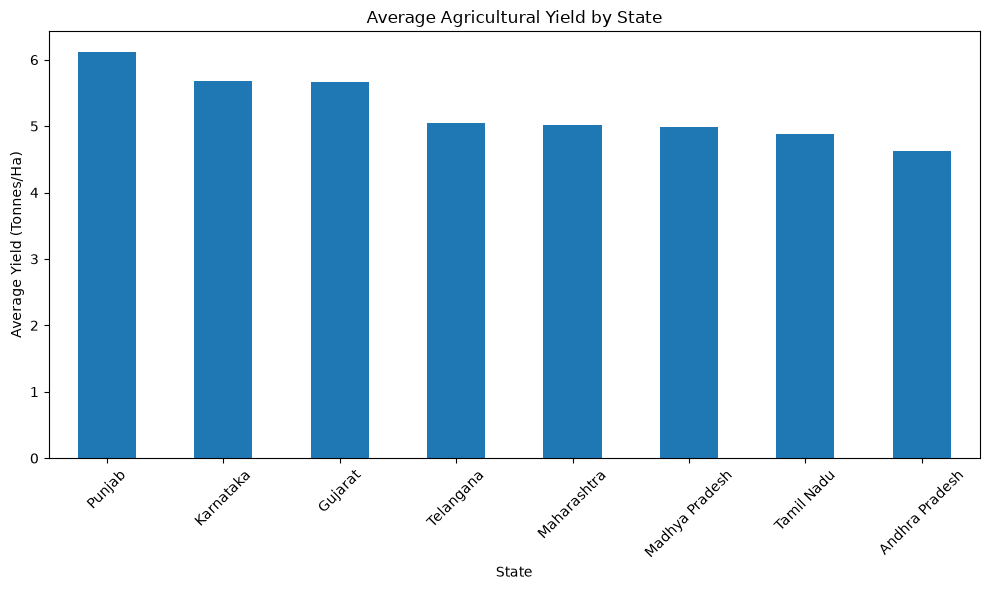

In [32]:
plt.figure(figsize=(10, 6))

state_yield.plot(kind="bar")

plt.title("Average Agricultural Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
correlation = df[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Farm_Area_Hectares",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR"
]].corr()

print("Correlation with Yield:")
print(correlation["Yield_Tonnes_Ha"].sort_values(ascending=False))

Correlation with Yield:
Yield_Tonnes_Ha       1.000000
Production_Tonnes     0.882813
Profit_INR            0.488466
Revenue_INR           0.432152
Water_Used_m3         0.386294
Rainfall_mm           0.030951
Farm_Area_Hectares    0.030203
Humidity_pct          0.012297
Avg_Temperature_C     0.009996
Fertilizer_kg_ha      0.000018
Pesticide_Litre_ha   -0.007779
Name: Yield_Tonnes_Ha, dtype: float64


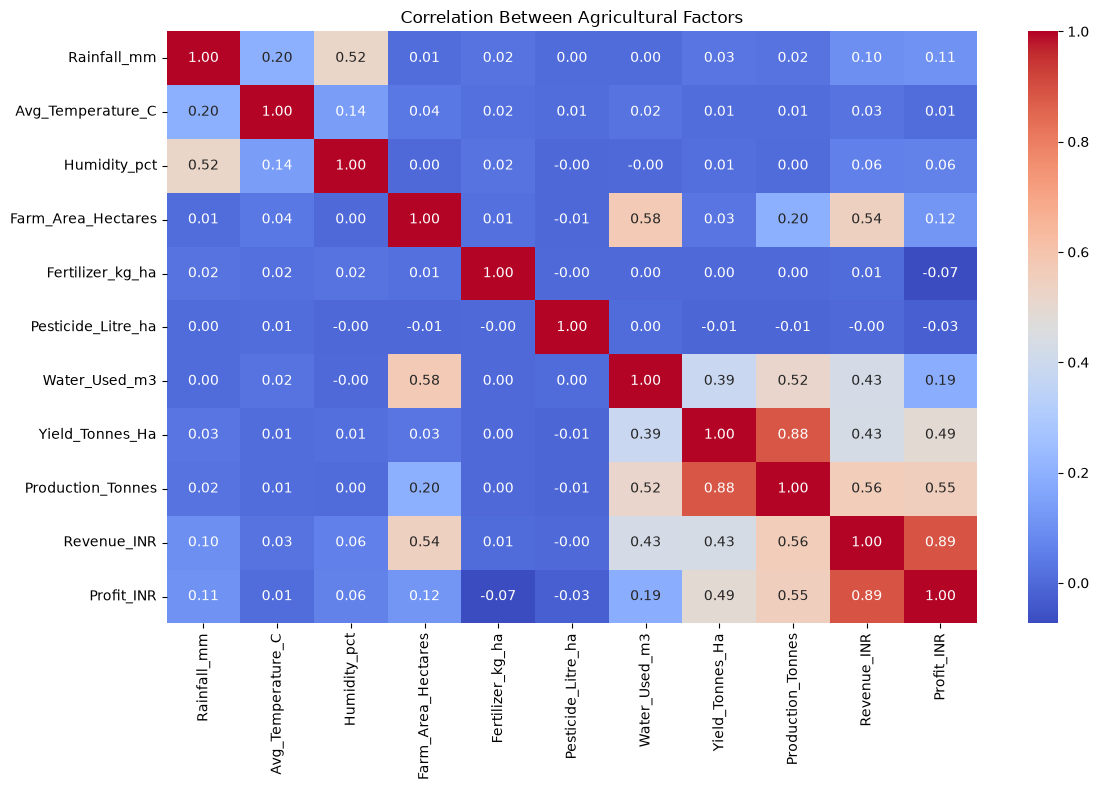

In [34]:
plt.figure(figsize=(12, 8))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Agricultural Factors")
plt.tight_layout()
plt.show()

In [35]:
best_yield_season = season_yield.idxmax()
best_production_season = season_production.idxmax()
best_profit_season = season_profit.idxmax()

print("Best Season by Yield:", best_yield_season)
print("Best Season by Production:", best_production_season)
print("Best Season by Profit:", best_profit_season)

Best Season by Yield: Kharif
Best Season by Production: Kharif
Best Season by Profit: Kharif


In [36]:
best_crop = crop_yield.idxmax()
best_crop_yield = crop_yield.max()

print("Best Performing Crop:", best_crop)
print("Average Yield:", round(best_crop_yield, 2), "Tonnes/Ha")

Best Performing Crop: Sugarcane
Average Yield: 46.64 Tonnes/Ha


In [37]:
crop_profit = (
    df.groupby("Crop")["Profit_INR"]
      .mean()
      .sort_values(ascending=False)
)

best_profit_crop = crop_profit.idxmax()
best_profit_value = crop_profit.max()

print("Most Profitable Crop:", best_profit_crop)
print("Average Profit:", round(best_profit_value, 2), "INR")

Most Profitable Crop: Sugarcane
Average Profit: 817187.99 INR


In [38]:
Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_limit) |
    (df["Yield_Tonnes_Ha"] > upper_limit)
]

print("Lower Yield Limit:", round(lower_limit, 2))
print("Upper Yield Limit:", round(upper_limit, 2))
print("Number of Unusual Yield Records:", len(outliers))

Lower Yield Limit: -1.62
Upper Yield Limit: 5.5
Number of Unusual Yield Records: 302


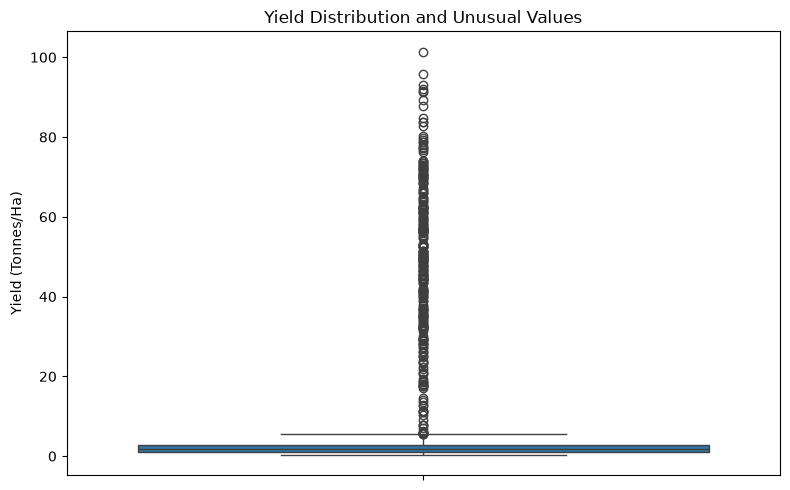

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["Yield_Tonnes_Ha"])

plt.title("Yield Distribution and Unusual Values")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [40]:
print("========== KEY PROJECT INSIGHTS ==========")

print("\n1. Best Season by Yield:")
print(best_yield_season)

print("\n2. Best Season by Production:")
print(best_production_season)

print("\n3. Best Season by Profit:")
print(best_profit_season)

print("\n4. Best Performing Crop:")
print(best_crop)

print("\n5. Most Profitable Crop:")
print(best_profit_crop)

print("\n6. Number of Unusual Yield Records:")
print(len(outliers))

print("\n==========================================")

========== KEY PROJECT INSIGHTS ==========

1. Best Season by Yield:
Kharif

2. Best Season by Production:
Kharif

3. Best Season by Profit:
Kharif

4. Best Performing Crop:
Sugarcane

5. Most Profitable Crop:
Sugarcane

6. Number of Unusual Yield Records:
302



In [41]:
print("========== PROJECT CONCLUSION ==========")

print("The analysis shows that agricultural performance varies across")
print("different seasons, crops, and geographical regions.")

print("Season-wise analysis helped compare yield, production,")
print("revenue, profit, resource usage, and environmental conditions.")

print("Crop-wise and state-wise analysis helped identify differences")
print("in agricultural performance.")

print("Correlation analysis helped examine relationships between")
print("environmental conditions, resource usage, yield, production,")
print("revenue, and profit.")

print("Outlier analysis helped identify unusual yield records.")

print("Overall, the analysis provides useful insights for better")
print("seasonal planning, resource management, and agricultural decisions.")

print("========================================")

========== PROJECT CONCLUSION ==========
The analysis shows that agricultural performance varies across
different seasons, crops, and geographical regions.
Season-wise analysis helped compare yield, production,
revenue, profit, resource usage, and environmental conditions.
Crop-wise and state-wise analysis helped identify differences
in agricultural performance.
Correlation analysis helped examine relationships between
environmental conditions, resource usage, yield, production,
revenue, and profit.
Outlier analysis helped identify unusual yield records.
Overall, the analysis provides useful insights for better
seasonal planning, resource management, and agricultural decisions.


In [42]:
print("========== RECOMMENDATIONS ==========")

print("1. Plan crop selection according to seasonal performance.")

print("2. Use water resources efficiently based on seasonal water requirements.")

print("3. Monitor rainfall, temperature, and humidity while planning farming activities.")

print("4. Identify high-performing crops and suitable regions for better productivity.")

print("5. Optimize fertilizer and pesticide usage to support efficient resource management.")

print("6. Monitor unusual yield values to identify possible risks or unusual farming conditions.")

print("7. Use data-driven insights to improve agricultural planning and profitability.")

print("=====================================")

========== RECOMMENDATIONS ==========
1. Plan crop selection according to seasonal performance.
2. Use water resources efficiently based on seasonal water requirements.
3. Monitor rainfall, temperature, and humidity while planning farming activities.
4. Identify high-performing crops and suitable regions for better productivity.
5. Optimize fertilizer and pesticide usage to support efficient resource management.
6. Monitor unusual yield values to identify possible risks or unusual farming conditions.
7. Use data-driven insights to improve agricultural planning and profitability.
